# Initialize

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pickle as pk
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load data

EMNIST data is available in the form of a csv file. Each row contains pixel values of an image and the corresponding label. The first column contains the label and the rest of the columns contain pixel values. The pixel values are in the range of 0 to 255. The images are of size 28x28.

In [3]:
# Load dataset
# -------------------------------
# Your code here
# -------------------------------


# Show the first 5 rows of the training dataset
# -------------------------------
# Your code here
# -------------------------------

,45,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.524,0.525,0.526,0.527,0.528,0.529,0.530,0.531,0.532,0.533
0,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,42,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Split the dataset into x_train, y_train, x_test, y_test
# -------------------------------
# Your code here
# -------------------------------

# Show dataset statistic
print('Training size: ', len(x_train), 'samples')
print('Testing size: ', len(x_test), 'samples')
print('Image shape: ',  x_train[0].shape)
print('Label : ', sorted(np.unique(y_train)))

Training size:  112799 samples
Testing size:  18799 samples
Image shape:  (784,)
Label :  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]


In [6]:
# Show Sample data from training dataset
print(x_train[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   2   4   4   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   2  22  82 114 114  50  21   3   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0   0   0
   3  67 170 232 245 245 220 170  79   8   0   0   

## Data Pre-processing

In [7]:
# Pre-Process dataset
print('Data Shape:', x_train.shape)

# Reshape the dataset to 28x28 (1 row to 2D image)
# -------------------------------
# Your code here
# -------------------------------

# Show Processed result
print('Data Shape:', x_train.shape)

Data Shape: (112799, 784)
Data Shape: (112799, 28, 28)


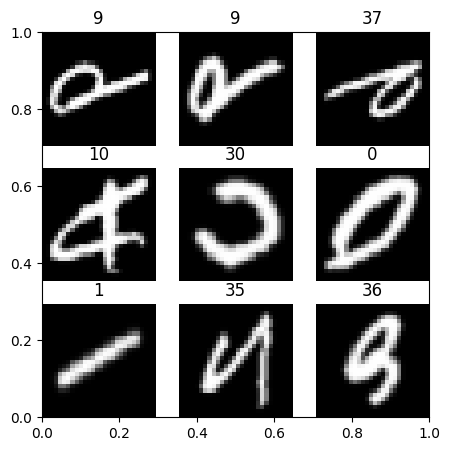

In [8]:
# Visualize sample dataset
inx =  np.random.randint(len(x_train), size=9)

plt.subplots(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[inx[i]], cmap='gray')
    plt.title(y_train[inx[i]])
    plt.axis('off')
plt.show()

It look like the data is wrong represented. We need to rotate the image 90 degrees and flip it horizontally to get the correct image.

In [10]:
# Image modify Function
# Note. cv2 is a library for image processing
import cv2
def image_processing(in_data):
    image = cv2.flip(in_data, 1)
    image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return image

In [11]:
# Modify images 
x_train = np.array([image_processing(x) for x in x_train])
x_test = np.array([image_processing(x) for x in x_test])

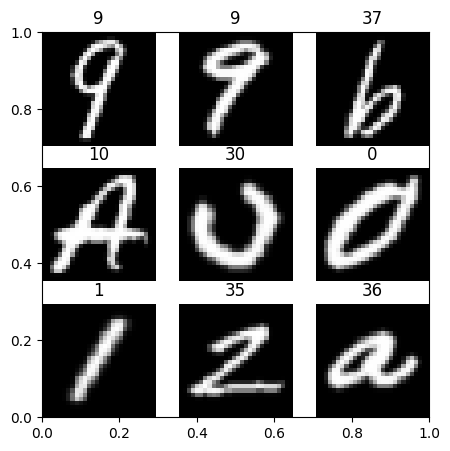

In [12]:
# Visualize sample dataset again
plt.subplots(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[inx[i]], cmap='gray')
    plt.title(y_train[inx[i]])
    plt.axis('off')
plt.show()

It still look like the label is worng. We need to decode the label to get the correct label.

In [13]:
# Modify label for visualization
# -------------------------------
# Your code here
# -------------------------------

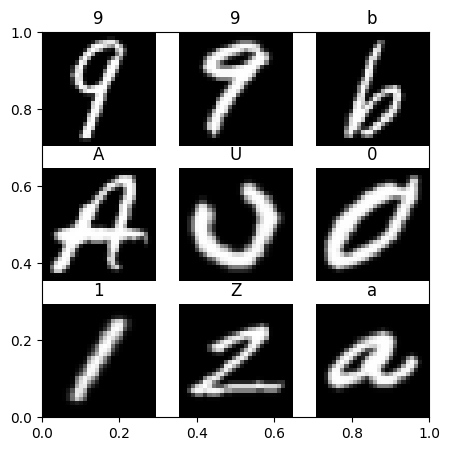

In [14]:
# Visualize sample dataset again
plt.subplots(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[inx[i]], cmap='gray')
    plt.title(y_train_label[inx[i]])
    plt.axis('off')
plt.show()

It look good now.

In [15]:
# Show sample image value/shape range
print('Train Max: ', max(np.unique(x_train)))
print('Train Min: ', min(np.unique(x_train)))
print('Test Max: ', max(np.unique(x_test)))
print('Test Min: ', min(np.unique(x_test)))
print('Train Shape: ', x_train.shape)
print('Test Shape: ', x_test.shape)

Train Max:  255
Train Min:  0
Test Max:  255
Test Min:  0
Train Shape:  (112799, 28, 28)
Test Shape:  (18799, 28, 28)


We need to normalize the pixel values to be in the range of 0 to 1.

In [16]:
# Normalize dataset to 0-1 from 0-255
# -------------------------------
# Your code here
# -------------------------------

# Show sample image value range
print('Train Max: ', max(np.unique(x_train)))
print('Train Min: ', min(np.unique(x_train)))
print('Test Max: ', max(np.unique(x_test)))
print('Test Min: ', min(np.unique(x_test)))

Train Max:  1.0
Train Min:  0.0
Test Max:  1.0
Test Min:  0.0


For the CNN, we need to reshape the data to be in the shape of (28, 28, 1).

In [17]:
# Reshape data to (W,H,C)
# -------------------------------
# Your code here
# -------------------------------

# Show sample image shape
print('Train Shape: ', x_train.shape)
print('Test Shape: ', x_test.shape)

Train Shape:  (112799, 28, 28, 1)
Test Shape:  (18799, 28, 28, 1)


Next, we need to encode the labels to be in the one-hot encoding format.

In [18]:
# convert class vectors to binary class matrices
num_classes = ... # Your code here
print('Classes: ', num_classes)

# Convert label to one-hot encoding
# -------------------------------
# Your code here
# -------------------------------

# Show sample label
print(y_train[inx[:3]])

Classes:  47
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


# Create Model
Let's create a simple CNN model with 2 convolutional layers and 2 dense layers.

In [20]:
# Find the input shape
input_shape = x_train.shape[1:]

# Create CNN model
# The model is a simple CNN with 2 Conv2D layers and 2 MaxPooling2D layers
# The filters are 32 and 64 for the first and second Conv2D layers respectively
# The output layer is a Dense layer with softmax activation function
# After each Conv2D layer, a ReLU activation function is added
# After the second Conv2D layer, a Flatten layer is added to convert the 2D output to 1D
# A dropout layer is added at the end to prevent overfitting with a dropout rate of 0.5
cnn = keras.Sequential(
    [
        layers.Conv2D(..., kernel_size=(3, 3), activation=..., input_shape=..., name='conv2D_1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Mpool_1'),
        layers.Conv2D(..., kernel_size=(3, 3), activation=..., name='conv2D_2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Mpool_2'),
        layers.Flatten(),
        layers.Dropout(...),
        layers.Dense(..., activation=..., name='conv1D'),
    ]
)


The created model should have the following architecture:
```python
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
=================================================================
 conv2D_1 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 Mpool_1 (MaxPooling2D)      (None, 13, 13, 32)        0         
                                                                 
 conv2D_2 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 Mpool_2 (MaxPooling2D)      (None, 5, 5, 64)          0         
                                                                 
 flatten_1 (Flatten)         (None, 1600)              0         
                                                                 
 dropout_1 (Dropout)         (None, 1600)              0         
                                                                 
 conv1D (Dense)              (None, 47)                75247     
                                                                 
=================================================================
Total params: 94,063
Trainable params: 94,063
Non-trainable params: 0
_________________________________________________________________
```

In [22]:
# Visualize Model
cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2D_1 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 Mpool_1 (MaxPooling2D)      (None, 13, 13, 32)        0         
                                                                 
 conv2D_2 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 Mpool_2 (MaxPooling2D)      (None, 5, 5, 64)          0         
                                                                 
 flatten_1 (Flatten)         (None, 1600)              0         
                                                                 
 dropout_1 (Dropout)         (None, 1600)              0         
                                                                 
 conv1D (Dense)              (None, 47)               

# Set Training Hyper-parameters
We will use the following hyper-parameters for training the model:
- Batch size: 512
- Number of epochs: 50
- Learning rate: 0.001
- Optimizer: Adam
- Loss function: Categorical Crossentropy
- Metrics: Accuracy

In [23]:
# Compile the model
batch_size = ... # Your code here
epochs = ... # Your code here
cnn.compile(loss =...,
            optimizer=...,
            metrics=...)

### Check the hardware environment
If we are using a GPU, the training will be faster.
The result of checking the hardware environment is somthing like this:
```python
Num GPUs Available: 1
GPU Name: /physical_device:GPU:0
```

In [24]:
# Check GPU is available or not
gpu_num = len(tf.config.list_physical_devices('GPU'))
print('Num GPUs Available: ', gpu_num)
if gpu_num > 0:
  gpu_name = tf.config.list_physical_devices('GPU')[0].name
  print('GPU Name: ', gpu_name)

Num GPUs Available:  0


# Train
Let's train the model using the training data and validate it using the validation data.

In [ ]:
# Train the model
# -------------------------------
# Your code here
# -------------------------------

Epoch 1/50
199/199 [==============================] - 7s 13ms/step - loss: 1.5311 - accuracy: 0.5725 - val_loss: 0.7364 - val_accuracy: 0.7745
Epoch 2/50
199/199 [==============================] - 2s 12ms/step - loss: 0.7459 - accuracy: 0.7681 - val_loss: 0.5628 - val_accuracy: 0.8184
Epoch 3/50
199/199 [==============================] - 2s 10ms/step - loss: 0.6222 - accuracy: 0.8026 - val_loss: 0.5028 - val_accuracy: 0.8370
Epoch 4/50
199/199 [==============================] - 2s 10ms/step - loss: 0.5599 - accuracy: 0.8209 - val_loss: 0.4750 - val_accuracy: 0.8385
Epoch 5/50
199/199 [==============================] - 2s 10ms/step - loss: 0.5180 - accuracy: 0.8333 - val_loss: 0.4439 - val_accuracy: 0.8496
Epoch 6/50
199/199 [==============================] - 2s 10ms/step - loss: 0.4938 - accuracy: 0.8382 - val_loss: 0.4314 - val_accuracy: 0.8531
Epoch 7/50
199/199 [==============================] - 2s 10ms/step - loss: 0.4732 - accuracy: 0.8451 - val_loss: 0.4147 - val_accuracy: 0.8591

# Model Evaluation

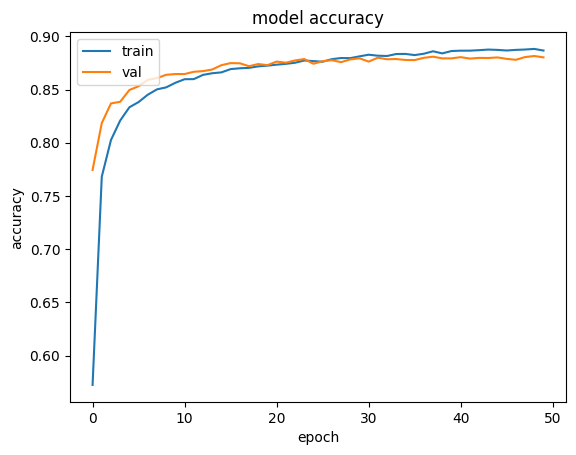

In [ ]:
# Plot accuracy
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

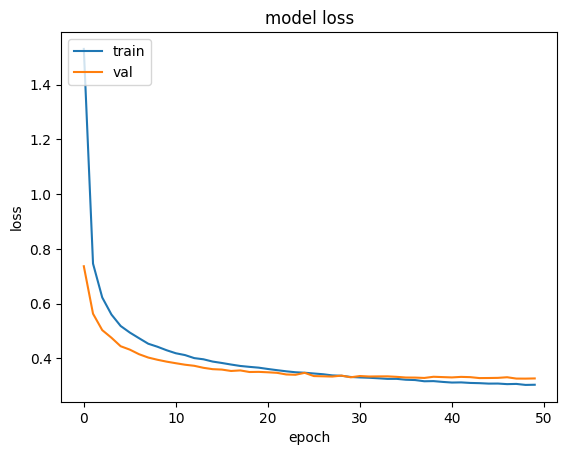

In [ ]:
# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [20]:
# Evaluate the model on the test data using `evaluate`
# -------------------------------
# Your code here
# -------------------------------

print("Test loss:", np.round(score[0], 4))
print("Test accuracy:", np.round(score[1], 4))

Test loss: 0.3501
Test accuracy: 0.8838


# Save Model

In [ ]:
# Save the model
# -------------------------------
# Your code here
# -------------------------------

---
---
---

# Use model

When we want to use the model, we need to load the model and use it to predict the label of the input image.
<br>We don't need to train the model again.!!!

In [ ]:
# Load the model
# Use keras.models.load_model() to load the model
# -------------------------------
# Your code here
# -------------------------------

In [21]:
# Predict the test data as a probability
# -------------------------------
# Your code here
# -------------------------------

588/588 [==============================] - 4s 7ms/step


In [22]:
# Show output probability
print(y_pred[0])

[5.4838623e-05 1.3923258e-08 3.1852217e-06 3.3131096e-04 2.2303445e-07
 8.9501918e-05 1.4980015e-12 2.9982486e-10 4.2747379e-06 1.8287899e-02
 1.9339254e-06 4.2704127e-05 4.3275358e-10 9.1479012e-07 8.0548146e-09
 7.7360746e-05 5.4636290e-05 9.5376457e-11 5.3923377e-09 4.3550455e-07
 1.4819724e-13 2.0580039e-07 7.6204182e-12 8.2069233e-11 3.9965498e-06
 5.9420042e-08 3.0394206e-06 6.9106817e-12 2.0973432e-04 1.5828042e-10
 2.5397837e-11 1.7025878e-12 3.9340109e-10 1.0901083e-10 8.2234561e-05
 4.0129039e-06 3.2667642e-06 2.4755780e-05 2.5726030e-09 1.2809534e-06
 1.4258207e-05 9.8009109e-01 4.3189168e-11 1.2430013e-11 6.1297766e-04
 1.0493397e-09 7.3359746e-10]


In [23]:
# Decode the output probability to class
# Use np.argmax() to find the class with the highest probability
# -------------------------------
# Your code here
# -------------------------------


# Show output class
print(y_pred_class[0], y_pred_class_label[0])

41 g


<ipython-input-24-5e26bd395e34>:7: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(5,5,i+1)


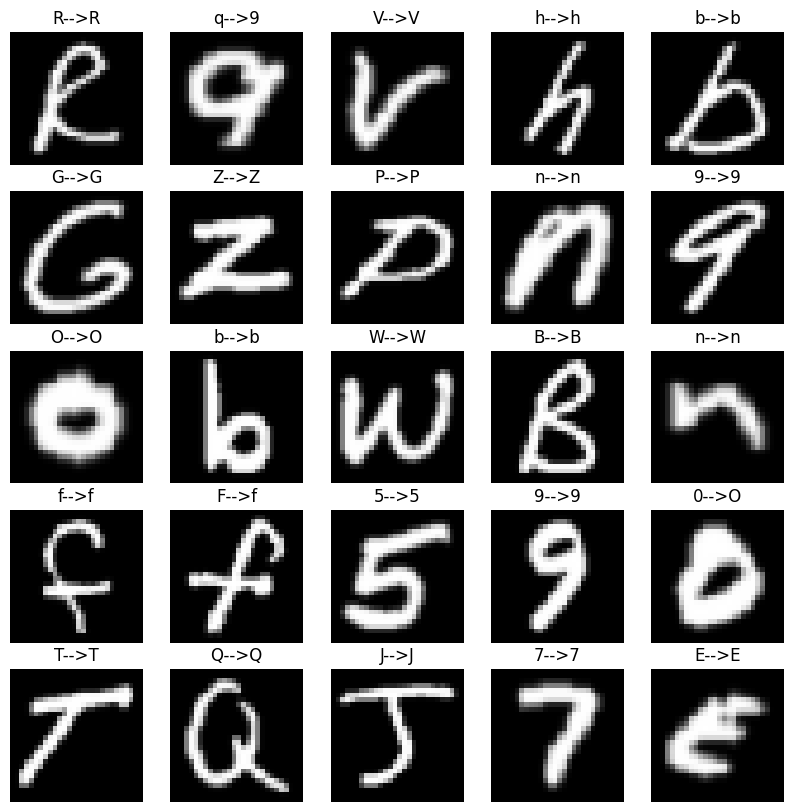

In [24]:
# Visualize sample dataset
inx =  np.random.randint(len(x_test), size=25)


plt.subplots(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[inx[i]], cmap='gray')
    plt.title(str(y_test_label[inx[i]])+'-->'+str(y_pred_class_label[inx[i]]))
    plt.axis('off')
plt.show()

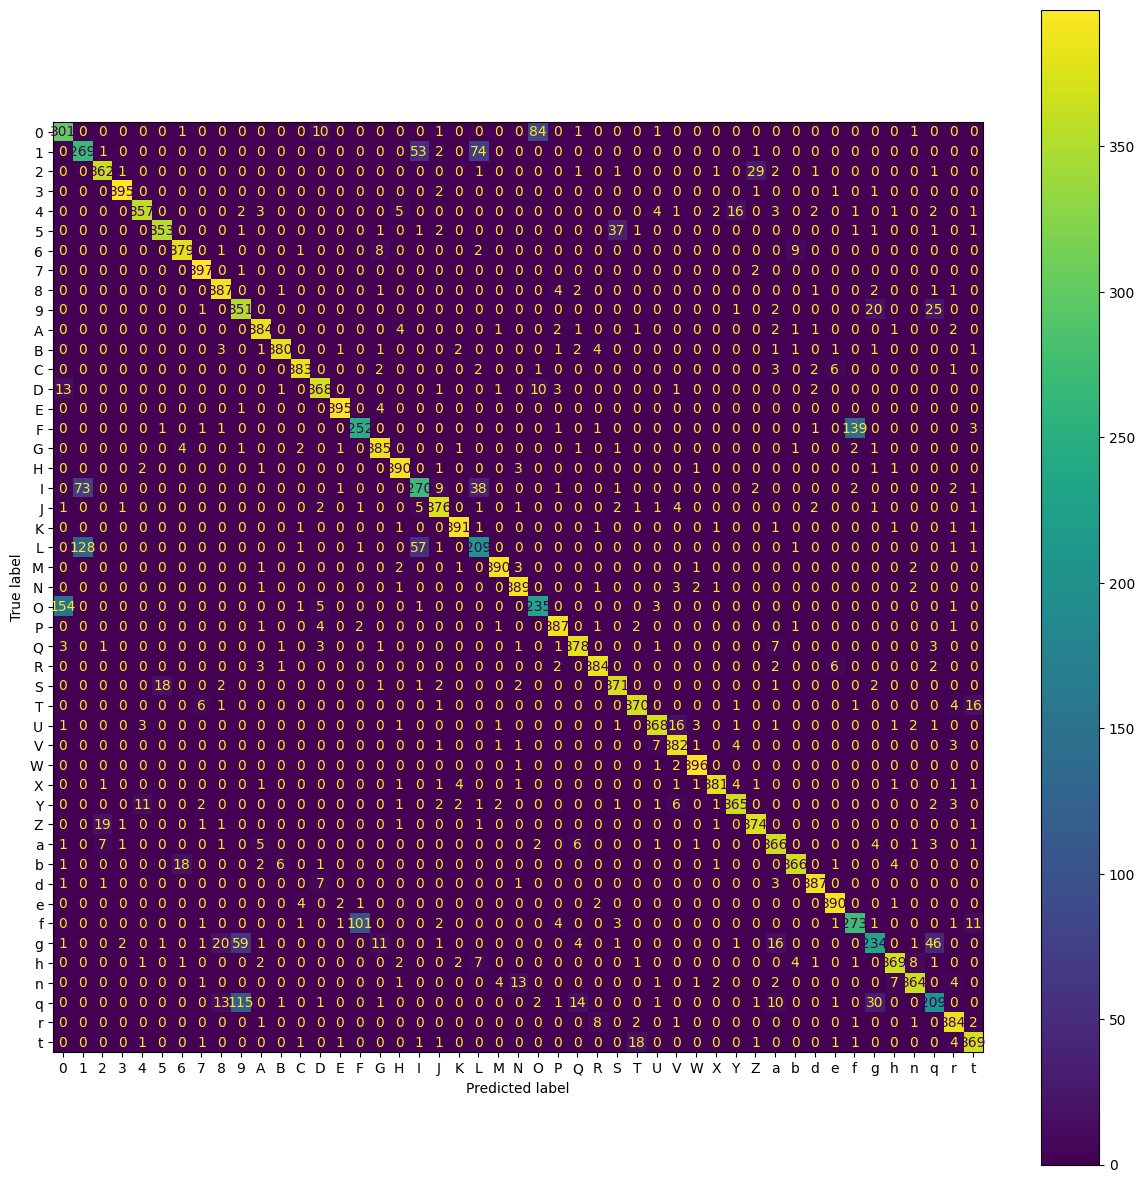

In [41]:
# Plot confusion matrix

# -------------------------------
# Your code here
# -------------------------------